In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

In [7]:
# читаем файл
def read_file(path):
    rows, start = [], False
    for line in open(path, encoding="utf-8", errors="ignore"):
        if "Freq" in line and "Range" in line:
            start = True
            continue
        if start:
            p = line.split()
            if len(p) >= 2:
                rows.append([float(p[0]), float(p[1])])
    return np.array(rows)

In [8]:
def cluster(X):
    Z = StandardScaler().fit_transform(X)
    rows = []

    # 5 алгоритмов
    for k in range(2, 7):
        rows.append((f"kmeans k={k}", KMeans(k, n_init=5, random_state=0).fit_predict(Z), np.nan, np.nan, "kmeans", k))
        rows.append((f"agglo k={k}", AgglomerativeClustering(k).fit_predict(Z), np.nan, np.nan, "agglo", k))
    for k in range(2, 7):
        g = GaussianMixture(k, random_state=0).fit(Z)
        rows.append((f"gmm k={k}", g.predict(Z), g.bic(Z), g.aic(Z), "gmm", k))
    for eps in (0.3, 0.5, 0.8):
        rows.append((f"dbscan eps={eps}", DBSCAN(eps=eps, min_samples=5).fit_predict(Z), np.nan, np.nan, "dbscan", eps))
    rows.append(("meanshift", MeanShift().fit_predict(Z), np.nan, np.nan, "meanshift", None))

    # 5 метрик
    table = []
    for name, lab, bic, aic, kind, param in rows:
        m = lab != -1
        Zm, lm = Z[m], lab[m]
        if len(set(lm)) < 2:
            continue
        table.append((name, lab, kind, param, dict(
            sil=silhouette_score(Zm, lm),
            ch=calinski_harabasz_score(Zm, lm),
            db=davies_bouldin_score(Zm, lm),
            bic=bic,
            aic=aic)))

    # нормируем и усредняем метрики
    keys = ["sil", "ch", "db", "bic", "aic"]
    higher = [True, True, False, False, False]
    score = np.zeros(len(table)); cnt = np.zeros(len(table))
    for key, hi in zip(keys, higher):
        v = np.array([r[4][key] if np.isfinite(r[4][key]) else np.nan for r in table])
        good = np.isfinite(v)
        if good.sum() < 2:
            continue
        o = np.argsort(v[good]); rk = np.empty(good.sum()); rk[o] = np.arange(good.sum()); rk /= (good.sum() - 1)
        score[good] += rk if hi else 1 - rk
        cnt[good] += 1
    score = score / np.maximum(cnt, 1)

    best = table[int(np.argmax(score))]
    kind, param = best[2], best[3]

    # обучаем
    if kind == "kmeans":
        labels = KMeans(param, n_init=5, random_state=0).fit_predict(Z)
    elif kind == "agglo":
        labels = AgglomerativeClustering(param).fit_predict(Z)
    elif kind == "gmm":
        labels = GaussianMixture(param, random_state=0).fit(Z).predict(Z)
    elif kind == "dbscan":
        labels = DBSCAN(eps=param, min_samples=5).fit_predict(Z)
    else:
        labels = MeanShift().fit_predict(Z)
    return best[0], labels


файл: files/input/clustering2test/2test/20230328-Belem
победитель: kmeans k=6 | кластеров: 6


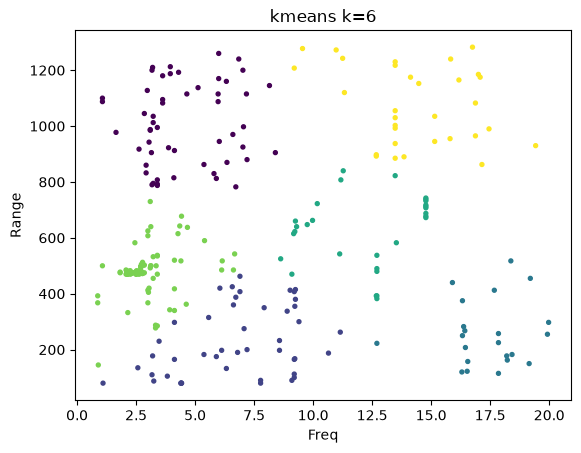

In [9]:
base = "files/input/clustering2test/2test/"
file = base + "20230328-Belem"        

X = read_file(file)
name, labels = cluster(X)
print("файл:", file)
print("победитель:", name, "| кластеров:", len(set(labels)) - (1 if -1 in labels else 0))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=8)
plt.xlabel("Freq"); plt.ylabel("Range"); plt.title(name)
plt.show()